# Problem 1: Line plots

In this problem, we will plot some daily weather data from a NOAA station in Millbrook, NY. A full description of this dataset is available at: https://www.ncdc.noaa.gov/data-access/land-based-station-data

The cell below uses pandas to download the data and populate a bunch of numpy arrays (t_daily_min, t_daily_max, etc.) Run the cell and then use the numpy arrays to try to re-create the plot you see.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [3]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


Text(0.5, 0, 'Date')

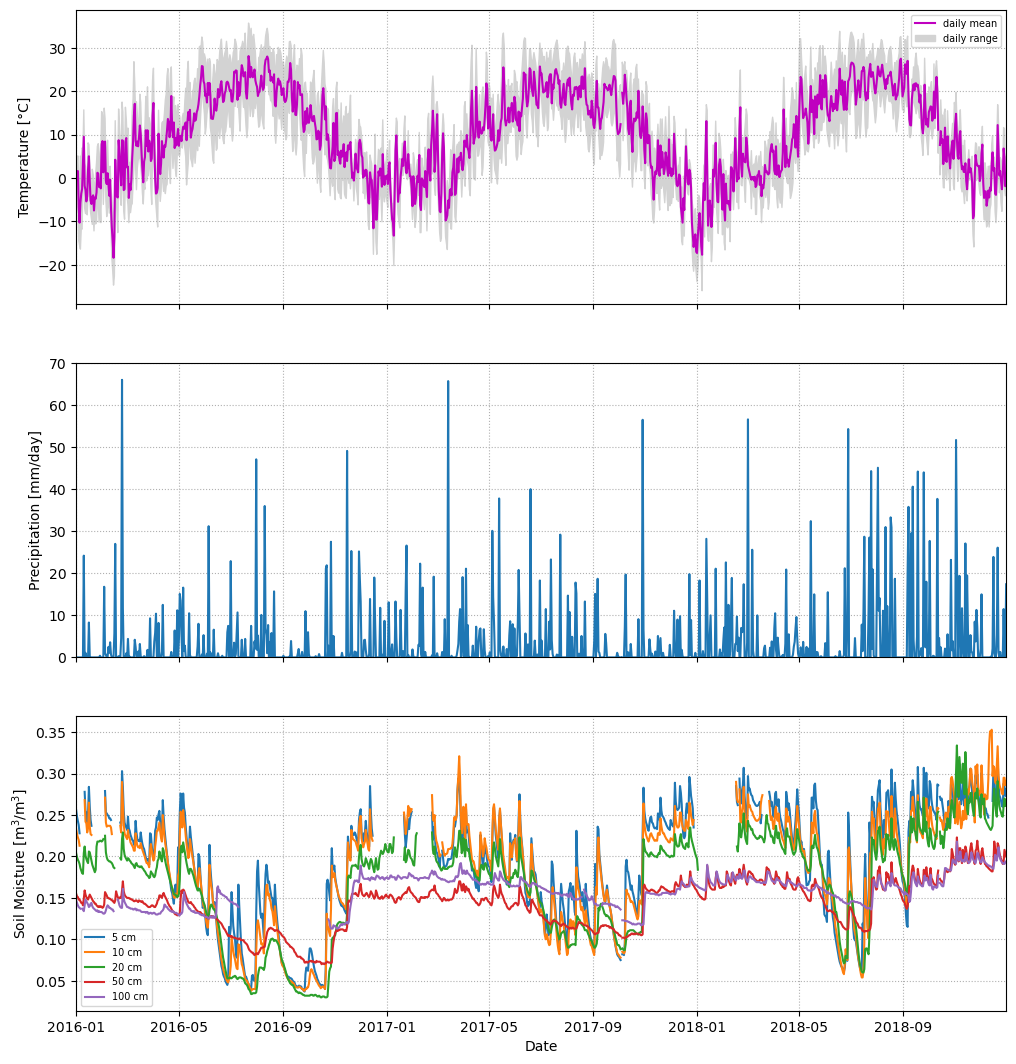

In [4]:
fig,axes = plt.subplots(figsize=(12,13),nrows=3,sharex = True)
axes[0].margins(x=0)
axes[0].plot(date,t_daily_mean,label = 'daily mean',color = 'm')
axes[0].grid(linestyle='dotted')
axes[0].fill_between(date,t_daily_min,t_daily_max,color = 'lightgrey', label='daily range')
axes[0].legend(loc='upper right',fontsize = 7)
axes[0].set_ylabel('Temperature [°C]')

axes[1].plot(date,p_daily_calc)
axes[1].grid(linestyle='dotted')
axes[1].set_ylabel('Precipitation [mm/day]')
axes[1].set_ylim(0,70)
axes[1].margins(x=0)

axes[2].plot(date,soil_moisture_5,label = '5 cm',color = 'tab:blue')
axes[2].plot(date,soil_moisture_10,label = '10 cm',color = 'tab:orange')
axes[2].plot(date,soil_moisture_20,label = '20 cm',color = 'tab:green')
axes[2].plot(date,soil_moisture_50,label = '50 cm',color = 'tab:red')
axes[2].plot(date,soil_moisture_100,label = '100 cm',color = 'tab:purple')
axes[2].grid(linestyle='dotted')
axes[2].legend(loc='lower left',fontsize = 7)
axes[2].set_ylabel('Soil Moisture [m$^{3}$/m$^{3}$]')
axes[2].set_xlabel('Date')

# Problem 2: Contour Plots

Now we will visualize some global temperature data from the NCEP-NCAR atmospheric reanalysis.

In [5]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


In [6]:
temp.shape

(94, 192)

In [7]:
lat.shape

(94,)

(-65.0, 30.0)

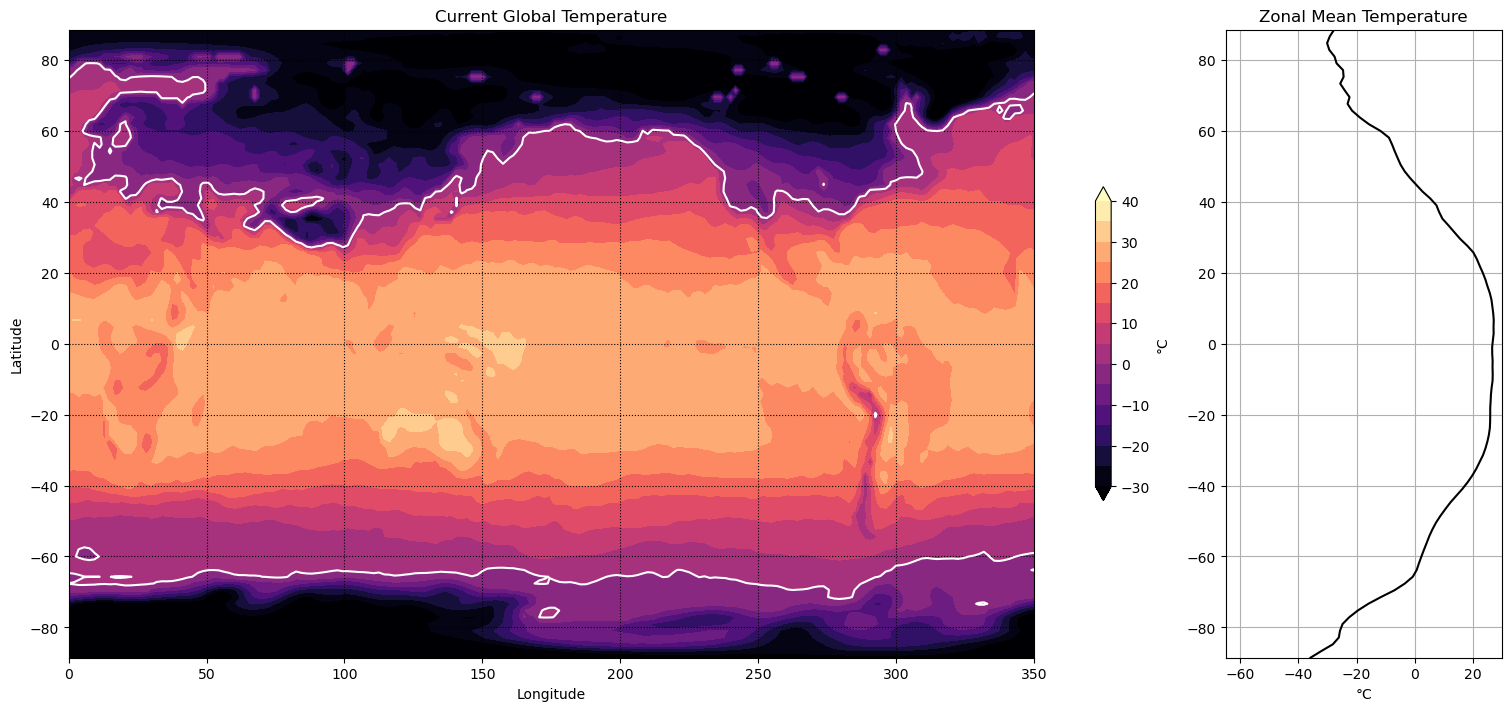

In [23]:
fig, ax = plt.subplots(figsize = (15,7),ncols = 2, gridspec_kw={'width_ratios': [3.5,1]}, layout='constrained', sharey=True)
clevels = np.arange(-30,45,5)
cf0 = ax[0].contourf(lon,lat,temp,levels = clevels, cmap='magma',extend = 'both')
ax[0].grid(linestyle='dotted',color='k')
ax[0].set_title('Current Global Temperature')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
ax[0].margins(x=0,y=0)
ax[0].set_xlim(0,350)
fig.colorbar(cf0,label= '°C', extend = 'both', shrink = 0.5)

ax[0].contour(lon,lat,temp, levels = 0,colors = 'white')

ax[1].grid()
mean_temp = np.mean(temp,axis=1)
ax[1].plot(mean_temp,lat,color = 'k')
ax[1].set_title('Zonal Mean Temperature')
ax[1].set_xlabel('°C')
ax[1].yaxis.set_tick_params(labelleft=True)
ax[1].set_xlim(-65,30)

# Problem 3: Scatter plots

Here we will make a map plot of earthquakes from a USGS catalog of historic large earthquakes. Color the earthquakes by log10(depth) and adjust the marker size to be magntiude^4
/100

In [10]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

In [11]:
depth

array([nan, nan, 18., ..., 26.,  9., 10.])

Text(0.5, 1.0, 'Location of Significant Earthquakes With Size Indicating Relative Magnitude')

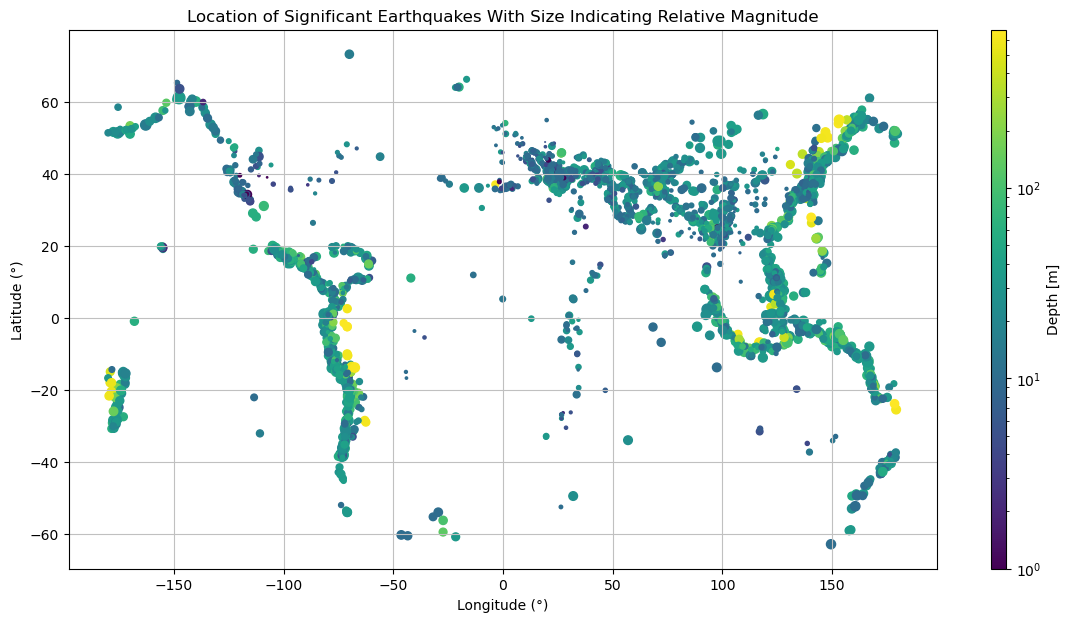

In [12]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(14,7))
splot = ax.scatter(longitude,latitude,s=((magnitude**4)/100),c=depth,norm=LogNorm())
ax.grid(color='silver')
fig.colorbar(splot,label= 'Depth [m]',aspect=35)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')